# Task 9: Support Vector Machines - Car Acceptability

Machine Learning Fundamentals

## Goal
Compare linear and polynomial SVM classifiers on the same held-out car records.

## Setup
Run all cells from top to bottom with Python 3. Required packages: numpy, pandas, matplotlib, scipy, scikit-learn, and IPython.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from IPython.display import display, Markdown

plt.rcParams.update({"figure.figsize": (7, 4), "font.size": 11,
                     "axes.spines.top": False, "axes.spines.right": False})
pd.set_option("display.max_columns", 8)
pd.set_option("display.width", 88)
SEED = 42
print("scikit-learn version:", sklearn.__version__)

scikit-learn version: 1.9.0


## Data
Use the provided car_acceptability.csv. The local coursework copy contains 1,727 records; it is used as supplied without filling in extra rows. All six inputs are treated as categorical, including door/person counts. Keep the data folder beside this notebook for offline execution; otherwise the GitHub copy is loaded.

### Check the input data

In [2]:
from pathlib import Path
import hashlib

local_paths = [Path("data/car_acceptability.csv"),
               Path("car_acceptability.csv")]
data_path = next((p for p in local_paths if p.exists()), None)
source = data_path or (
    "https://raw.githubusercontent.com/programmingxpert/"
    "Machine-Learning-Fundamentals/main/"
    "Jupyter%20Notebook%20files/data/car_acceptability.csv"
)
cars = pd.read_csv(source, dtype=str)
print("Rows and columns:", cars.shape)
print("Missing values:", int(cars.isna().sum().sum()))
print("Duplicate rows:", int(cars.duplicated().sum()))
assert not cars.isna().any().any()
assert not cars.duplicated().any()
display(cars.head())
print("Class counts:")
print(cars["evaluation"].value_counts().to_string())

Rows and columns: (1727, 7)
Missing values: 0
Duplicate rows: 0


,buying price,maintenance cost,number of doors,number of persons,lug_boot,safety,evaluation
0,vhigh,vhigh,2,2,small,med,unacc
1,vhigh,vhigh,2,2,small,high,unacc
2,vhigh,vhigh,2,2,med,low,unacc
3,vhigh,vhigh,2,2,med,med,unacc
4,vhigh,vhigh,2,2,med,high,unacc


Class counts:
evaluation
unacc    1209
acc       384
good       69
vgood      65


## Method
Use an 80/20 stratified split to retain class proportions. Fit one-hot encoding only on the training partition through a pipeline. This avoids imposing arbitrary numerical distances between categories. The seed makes the split reproducible. Accuracy is supplemented by macro F1 and balanced accuracy because the classes are imbalanced.

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, classification_report,
    ConfusionMatrixDisplay, f1_score
)

features = cars.drop(columns="evaluation")
target = cars["evaluation"]
train_x, test_x, train_y, test_y = train_test_split(
    features, target, test_size=0.2, stratify=target, random_state=SEED
)
class_order = ["unacc", "acc", "good", "vgood"]
print(f"Training rows: {len(train_x)}; test rows: {len(test_x)}")
print("Majority-class test baseline:",
      round((test_y == train_y.mode()[0]).mean(), 4))

Training rows: 1381; test rows: 346
Majority-class test baseline: 0.6994


### Fit both kernels
The linear kernel uses a linear boundary in the encoded feature space. A degree-3 polynomial kernel adds feature interactions. Binary one-hot inputs already share a common scale. Both models use C=1; no test-driven tuning is performed.

In [4]:
from sklearn.svm import SVC

models, predicted, records = {}, {}, []
for kernel in ("linear", "poly"):
    model = make_pipeline(
        OneHotEncoder(handle_unknown="ignore"),
        SVC(kernel=kernel, C=1.0, degree=3, gamma="scale")
    )
    model.fit(train_x, train_y)
    labels = model.predict(test_x)
    models[kernel], predicted[kernel] = model, labels
    records.append({
        "Kernel": kernel,
        "Accuracy": accuracy_score(test_y, labels),
        "Balanced accuracy": balanced_accuracy_score(test_y, labels),
        "Macro F1": f1_score(test_y, labels, average="macro")
    })
results = pd.DataFrame(records).set_index("Kernel")
print(results.round(4).to_string())

        Accuracy  Balanced accuracy  Macro F1
Kernel                                       
linear    0.9364             0.8661    0.8715
poly      0.9971             0.9968    0.9897


## Results
### Linear SVM

              precision    recall  f1-score   support

       unacc       0.97      0.98      0.97       242
         acc       0.87      0.86      0.86        77
        good       0.69      0.79      0.73        14
       vgood       1.00      0.85      0.92        13

    accuracy                           0.94       346
   macro avg       0.88      0.87      0.87       346
weighted avg       0.94      0.94      0.94       346



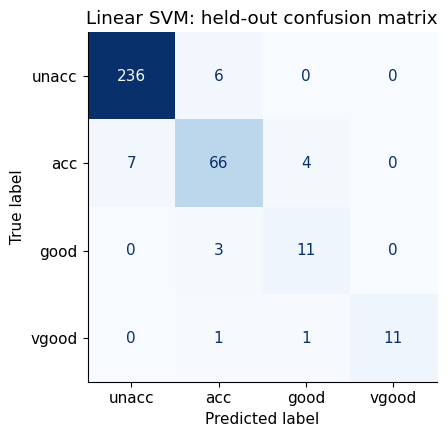

In [5]:
print(classification_report(test_y, predicted["linear"],
                            labels=class_order, zero_division=0))
fig, ax = plt.subplots(figsize=(6, 4.5))
ConfusionMatrixDisplay.from_predictions(
    test_y, predicted["linear"], labels=class_order,
    cmap="Blues", colorbar=False, ax=ax
)
ax.set_title("Linear SVM: held-out confusion matrix")
plt.tight_layout()
plt.show()

### Polynomial SVM

              precision    recall  f1-score   support

       unacc       1.00      1.00      1.00       242
         acc       1.00      0.99      0.99        77
        good       0.93      1.00      0.97        14
       vgood       1.00      1.00      1.00        13

    accuracy                           1.00       346
   macro avg       0.98      1.00      0.99       346
weighted avg       1.00      1.00      1.00       346


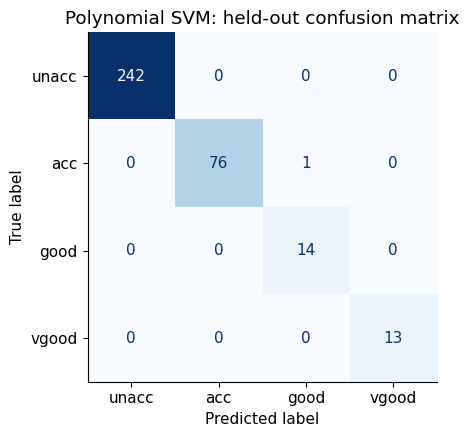

In [6]:
print(classification_report(test_y, predicted["poly"],
                            labels=class_order, zero_division=0))
fig, ax = plt.subplots(figsize=(6, 4.5))
ConfusionMatrixDisplay.from_predictions(
    test_y, predicted["poly"], labels=class_order,
    cmap="Blues", colorbar=False, ax=ax
)
ax.set_title("Polynomial SVM: held-out confusion matrix")
plt.tight_layout()
plt.show()

## Takeaways

In [7]:
display(Markdown(
    f"Linear SVM accuracy was **{results.loc['linear', 'Accuracy']:.1%}**, "
    f"compared with **{results.loc['poly', 'Accuracy']:.1%}** for the "
    "polynomial kernel on the same test set. Compare macro F1 and the "
    "confusion matrices to assess minority-class performance. This is "
    "a descriptive kernel comparison on one split; choosing hyperparameters "
    "for deployment would require validation within the training data."
))

Linear SVM accuracy was **93.6%**, compared with **99.7%** for the polynomial kernel on the same test set. Compare macro F1 and the confusion matrices to assess minority-class performance. This is a descriptive kernel comparison on one split; choosing hyperparameters for deployment would require validation within the training data.

## Reference and reproducibility
Task scope reference: [Aishani's Task 9 notebook](https://github.com/aishani-dutta1397/Machine-Learning-Fundamentals-Work/blob/main/T9_SVM.ipynb). The reference was consulted for the exercise scope; the code, explanations, validation, and presentation here were independently written. Outputs are generated by the cells above. Cluster numbers, where used, are arbitrary identifiers.